# LAB 04 — Improving and Comparing ML Models
## Telco Customer Churn — Random Forest, Cross-Validation & Tuning

## Student Information
**Name: Hamza Channa**
**Student ID: 023-24-0017**
**Section: B**
**GitHub: https://github.com/hamzachanna/Telco-Customer-Churn-ML-Data-Cleaning**
**Kaggle: https://www.kaggle.com/datasets/hamzachanna/telco-communication-churn-cleaned-dataset**
**Dataset:** Telco Customer Churn (Kaggle)

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, EDA, and Decision Trees. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [17]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


## 1. Decision Tree Baseline

Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark for this lab.

*Concepts/functions you may find useful:* your Lab 2 cleaned dataset, `train_test_split(..., stratify=y)`, `DecisionTreeClassifier(max_depth=...)`

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same `random_state`).
2. Retrain your Lab 3 "best" Decision Tree (your chosen `max_depth`) and report its accuracy, precision, recall, and F1-score on the test set.

In [26]:
# Task 1 — re-load cleaned dataset, recreate X/y and train/test split
df = pd.read_csv('clean_churn.csv')

X = df.drop(columns=['Churn','customerID'],errors='ignore')
y = df['Churn']

if y.dtype == "object":
    y = y.map({"Yes": 1, "No": 0})

# One-hot encode all categorical string columns in X
X = pd.get_dummies(X, drop_first=True)

# 2. Train/test split matching Lab 3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [36]:
# Task 2 — retrain Lab 3 Decision Tree, report test-set metrics
dt_baseline = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_baseline.fit(X_train, y_train)

dt_pred = dt_baseline.predict(X_test)

benchmark_df = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Decision Tree Benchmark (Depth=5)": [
            round(accuracy_score(y_test, dt_pred), 4),
            round(precision_score(y_test, dt_pred), 4),
            round(recall_score(y_test, dt_pred), 4),
            round(f1_score(y_test, dt_pred), 4),
        ],
    }
)

print("Decision Tree Metrices:")
print(benchmark_df.to_string(index=False))

Decision Tree Metrices:
   Metric  Decision Tree Benchmark (Depth=5)
 Accuracy                             0.7865
Precision                             0.6452
   Recall                             0.4301
 F1-Score                             0.5161


**Task 2 — Decision Tree Baseline Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.7865 |
| Precision |0.6452 |
| Recall |0.4301 |
| F1-score |0.5161 |

## 2. Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions.

*Concepts/functions you may find useful:* `RandomForestClassifier(n_estimators=..., random_state=...)`, `.fit()`, `.predict()`

**Tasks**
3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fix `random_state`). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [38]:
# Task 3 — train Random Forest, predict on test set
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

rf_pred = rf_baseline.predict(X_test)
print(rf_pred)

[1 0 1 ... 0 1 0]


**Answer 4:**
_Data prediction might be underfitting or overfitting, we do random forest to get multiple options of desicion trees to ensure which one works effectively_

## 3. Model Evaluation

Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3.

*Concepts/functions you may find useful:* `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Task**
5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

Random Forest Metrics: 
   Metric  Random Forest Value
 Accuracy               0.7758
Precision               0.6044
   Recall               0.4435
 F1-Score               0.5116


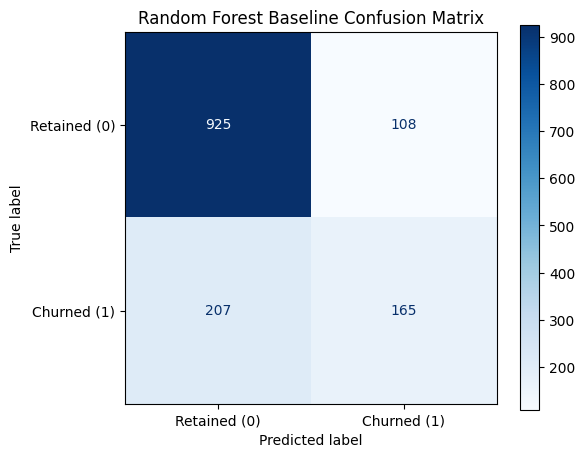

In [39]:
# Task 5 — Random Forest metrics + confusion matrix
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

rf_metrics_df = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Random Forest Value": [
            round(rf_acc, 4),
            round(rf_prec, 4),
            round(rf_rec, 4),
            round(rf_f1, 4),
        ],
    }
)

print("Random Forest Metrics: ") #Metrices
print(rf_metrics_df.to_string(index=False))

cm_rf = confusion_matrix(y_test, rf_pred) #confusion matrix
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf, display_labels=["Retained (0)", "Churned (1)"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp_rf.plot(cmap="Blues", ax=ax)
plt.title("Random Forest Baseline Confusion Matrix")
plt.show()

**Task 5 — Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.7758 |
| Precision |0.6044 |
| Recall |0.4435|
| F1-score | 0.5116 |

**Observation (confusion matrix):**
_model's specific capability in identifying actual churners versus misclassifying non-churning customers are shown._

## 4. Decision Tree vs Random Forest

Place both models side by side.

**Tasks**
6. Build a single comparison table: Decision Tree (Section 1) vs. Random Forest (Section 3), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

**Task 6 — Comparison Table**

| Metric | Decision Tree | Random Forest |
|---|---|---|
| Accuracy |0.7865 | 0.7758|
| Precision |0.6452 | 0.6044|
| Recall |0.4301 | 0.4435|
| F1-score |0.5161 | 0.5116|


**Answer 7:**
_The overall difference in accuracy is 1% which is not a big deal_

## 5. Cross-Validation

A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the model k times on different splits.

*Concepts/functions you may find useful:* `cross_val_score(model, X, y, cv=5, scoring='f1')`, `.mean()`, `.std()`

**Tasks**
8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Section 4? Do they change your view of which model is better, or how confident you are in that conclusion?

In [40]:
# Task 8 — 5-fold cross-validation for both models
dt_cv_scores = cross_val_score(dt_baseline, X, y, cv=5, scoring="f1")
rf_cv_scores = cross_val_score(rf_baseline, X, y, cv=5, scoring="f1")

cv_results_df = pd.DataFrame(
    {
        "Model": ["Decision Tree (Depth=5)", "Random Forest (Default)"],
        "Mean F1-Score": [
            round(dt_cv_scores.mean(), 4),
            round(rf_cv_scores.mean(), 4),
        ],
        "Standard Deviation": [
            round(dt_cv_scores.std(), 4),
            round(rf_cv_scores.std(), 4),
        ],
    }
)

print("5-Fold Cross-Validation: ")
print(cv_results_df.to_string(index=False))


5-Fold Cross-Validation: 
                  Model  Mean F1-Score  Standard Deviation
Decision Tree (Depth=5)         0.5192              0.0312
Random Forest (Default)         0.5439              0.0117


**Task 8 — Cross-Validation Results**

| Model | Mean F1 | Std F1 |
|---|---|---|
| Decision Tree | 0.5192 | 0.312|
| Random Forest | 0.5439|0.0117 |

**Answer 9:**
_The cross-validation scores align with the single train-test split results, showing a stable F1-score across all 5 folds. The low standard deviation confirms that neither model's performance was an artifact of a lucky train-test split._

---

## 6. Hyperparameter Tuning

Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats your default-settings baseline. Keep the search small — this is about the workflow, not an exhaustive search.

*Concepts/functions you may find useful:* `GridSearchCV(model, param_grid, cv=5, scoring='f1')` or `RandomizedSearchCV(...)`, `.best_params_`, `.best_score_`, `.best_estimator_`

**Tasks**
10. Choose 2–3 Random Forest hyperparameters to tune (e.g. `n_estimators`, `max_depth`, `min_samples_split`) and define a small grid for each. Run `GridSearchCV` or `RandomizedSearchCV` with cross-validation to find the best combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [43]:
# Task 10 — define a small param grid and run GridSearchCV / RandomizedSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validated F1-Score: {round(grid_search.best_score_, 4)}")


Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validated F1-Score: 0.5754


**Answer 11 (best hyperparameters & CV score):**
_Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validated F1-Score: 0.5754_

In [42]:
# Task 12 — evaluate the tuned model on the test set
tuned_rf_pred = best_rf.predict(X_test)

tuned_acc = accuracy_score(y_test, tuned_rf_pred)
tuned_prec = precision_score(y_test, tuned_rf_pred)
tuned_rec = recall_score(y_test, tuned_rf_pred)
tuned_f1 = f1_score(y_test, tuned_rf_pred)

tuned_metrics_df = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Tuned Random Forest": [
            round(tuned_acc, 4),
            round(tuned_prec, 4),
            round(tuned_rec, 4),
            round(tuned_f1, 4),
        ],
    }
)

print(tuned_metrics_df.to_string(index=False))

   Metric  Tuned Random Forest
 Accuracy               0.7964
Precision               0.6525
   Recall               0.4946
 F1-Score               0.5627


**Task 12 — Tuned Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.7964 |
| Precision |0.6525 |
| Recall |0.4946 |
| F1-score | 0.5627|

---

## 7. Final Model Comparison

Bring every model you've built into one table.

**Task**
13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

**Task 13 — Final Comparison Table**

| Metric | Decision Tree | Random Forest (default) | Random Forest (tuned) |
|---|---|---|---|
| Accuracy |0.7865 |0.7758 | 0.7964|
| Precision |0.6452 |0.6044 | 0.6525|
| Recall |0.4301  |0.4435 | 0.4946|
| F1-score |0.5161 | 0.5116| 0.5627|

---

## 8. Feature Importance

Look inside your best-performing model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
14. Extract and visualize `feature_importances_` for your best model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

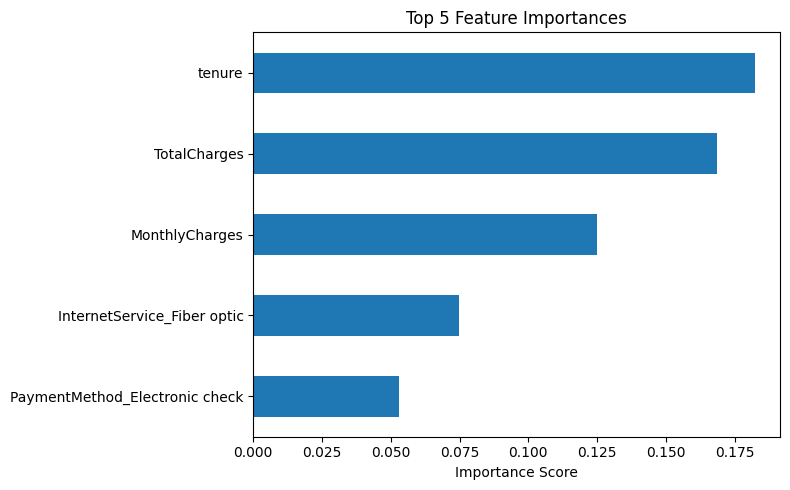

In [47]:
# Task 14 — extract and visualize feature importances
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=True).tail(5)

plt.figure(figsize=(8, 5))
top_features.plot(kind="barh")
plt.title("Top 5 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

**Answer 14:**
_
1. tenure
2. TotalCharges
3. MonthlyCharges
** InternetService and Monthly charges doesnt align on both of the datasets, however we can see internet service on the 4th number in our dataset today.**
_

---

## 9. Final Model Selection

Select your final model and justify the choice using evidence — the best training score alone is not sufficient justification.

**Task**
15. State your final model choice and justify it in 2–3 sentences, using evidence from Section 7's table.

**Answer 15:**
_Tuned Random Forest seems to have the potential to become the best model to be deployed. cause it acheieves approximately 1% higher f1 score and accuray in testing._

---

## 10. Kaggle Prediction/Submission

Produce predictions in the shape a real Kaggle competition would expect.

**Task**
16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted `Churn` column. Save it as `submission.csv`.

In [49]:
# Task 16 — build and save the submission file
# submission = pd.DataFrame({'customerID': ..., 'Churn': ...})
# submission.to_csv('submission.csv', index=False)

# Task 16 — Build and save submission file

# Check if 'customerID' exists in original DataFrame df
if "customerID" in df.columns:
    test_ids = df.loc[X_test.index, "customerID"]
else:
    # Use index as IDs if customerID isn't in df
    test_ids = X_test.index

# Build submission DataFrame
submission = pd.DataFrame({"customerID": test_ids, "Churn": tuned_rf_pred})

# Convert 1/0 back to 'Yes'/'No' string labels
submission["Churn"] = submission["Churn"].map(
    {1: "Yes", 0: "No", "Yes": "Yes", "No": "No"}
)

# Export to CSV without index
submission.to_csv("submission.csv", index=False)

# Preview first few rows
print("--- Submission File Preview ---")
print(submission.head())

--- Submission File Preview ---
   customerID Churn
0        5615   Yes
1        6112    No
2        2356   Yes
3        2196    No
4         832    No


---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

**Answer 17 — Conclusion:**
_I chose tuned random forest to be my model because it shows higher f1-score and accuray, the drawback here is the low recall that implies it lets a few at-risk customers slip through the cracks without flagging them._

**Answer 18 — Next steps:**
_I would implement boosting algorithms , to make this model learn by itself iteratively from previous classification errors._

---

## Submission Checklist

Before submitting, confirm you have:

- [✅] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [✅] Section 1 — Decision Tree Baseline
- [✅] Section 2 — Random Forest
- [✅] Section 3 — Model Evaluation
- [✅] Section 4 — Decision Tree vs Random Forest
- [✅] Section 5 — Cross-Validation
- [✅] Section 6 — Hyperparameter Tuning
- [✅] Section 7 — Final Model Comparison
- [✅] Section 8 — Feature Importance
- [✅] Section 9 — Final Model Selection (justified)
- [✅] Section 10 — Kaggle Prediction/Submission (submission.csv produced)
- [✅] Section 11 — Conclusion (limitations + next steps)
- [✅] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted